In [2]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

In [3]:
# Update the path to your data file
DATA_PATH = '../data/raw/groceries.csv'

# Load the data
df = pd.read_csv(DATA_PATH)

# Initial Data Report
data_source_report = {
    "source": "Coursework Provided Dataset",
    "acquisition_method": "CSV File Load",
    "date_acquired": "2026-03-30",
    "issues_encountered": ["None during initial load"]
}

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 38765 rows x 3 columns


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [4]:
# Inspect data types and non-null counts
print("--- Data Info ---")
df.info()

print("\n--- Descriptive Statistics (Categorical) ---")
# Since your data is mostly strings (Member_number and itemDescription)
print(df.describe(include='all'))

print("\n--- Top 10 Most Frequent Items ---")
print(df['itemDescription'].value_counts().head(10))

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB

--- Descriptive Statistics (Categorical) ---
        Member_number        Date itemDescription
count    38765.000000       38765           38765
unique            NaN         728             167
top               NaN  21-01-2015      whole milk
freq              NaN          96            2502
mean      3003.641868         NaN             NaN
std       1153.611031         NaN             NaN
min       1000.000000         NaN             NaN
25%       2002.000000         NaN             NaN
50%       3005.000000         NaN             NaN
75%       4007.000000         NaN             NaN
m

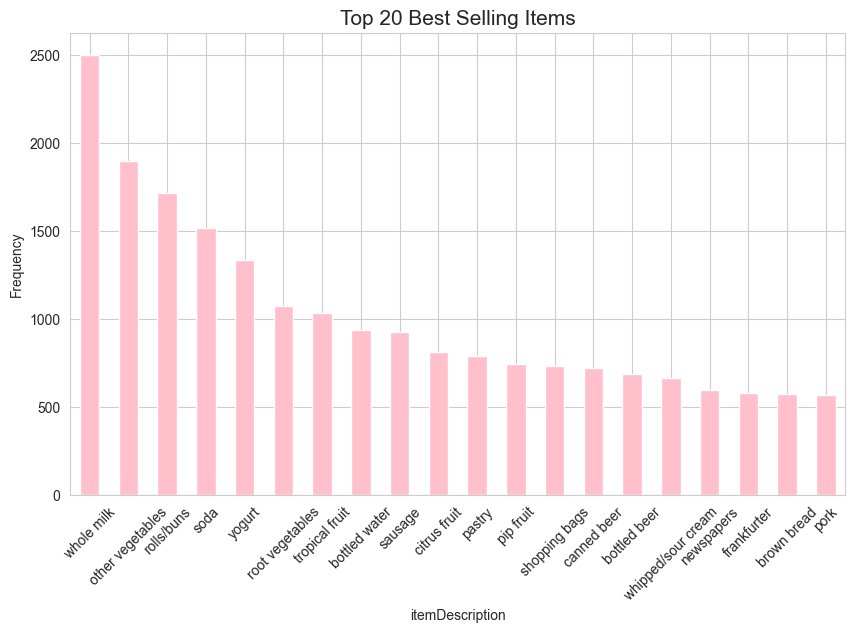

1. Insight 1: 'whole milk' appears to be the most frequent item in the dataset.
2. Insight 2: The dataset consists of Member IDs, Dates, and Item Descriptions.
3. Hypothesis 1: Customers buying 'whole milk' are likely to also buy 'pastry' or 'vegetables'.


In [5]:
# Explore the distribution of items
plt.figure(figsize=(10, 6))
df['itemDescription'].value_counts().head(20).plot(kind='bar', color='pink')
plt.title('Top 20 Best Selling Items', fontsize=15)
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

initial_insights = [
    "Insight 1: 'whole milk' appears to be the most frequent item in the dataset.",
    "Insight 2: The dataset consists of Member IDs, Dates, and Item Descriptions.",
    "Hypothesis 1: Customers buying 'whole milk' are likely to also buy 'pastry' or 'vegetables'."
]
for i, insight in enumerate(initial_insights, 1):
    print(f"{i}. {insight}")

In [6]:
# Check for missing values
missing = df.isnull().sum()
print("=== Missing Values Report ===")
print(missing)

# Check for duplicate records
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Note: In Phase 3 (Preparation), we will handle these duplicates.
if duplicates > 0:
    print("\nSample of duplicate rows found. These will be removed in the next phase.")

=== Missing Values Report ===
Member_number      0
Date               0
itemDescription    0
dtype: int64

Number of duplicate rows: 759

Sample of duplicate rows found. These will be removed in the next phase.
